# 시계열 사전과제

## 1. 시계열 데이터  
  
### 1-1. 시계열 데이터 정의  
  
**시계열 데이터**  
- 순차적인 시간에 흐름에 따라 수집된 데이터
- 연속한 관측치는 서로 상관관계 존재
- 순서가 중요한 '시퀀스 데이터'
- 단순 시간-수치로 이루어진 데이터 뿐 아니라, 단어의 순서가 중요한 NLP 데이터에도 동일한 개념 적용 가능
- "과거 데이터가 미래에 어떤 영향을 미치는가?"에 집중
- 의학, 경제학, 기상학, 천문학 등 다양한 분야에 활용
  

**단변량 시계열/다변량 시계열**  
1. 단변량 시계열: *하나의 숫자*가 시간에 따라 변하는 것
- 시간에 따라 연속적으로 측정된 단일 변수로 이루어진 시계열 데이터
- 시간에 흐름에 따른 패턴, 트렌드 이해
- 사례: 주식 가격, 온도, 매출 데이터 등
  
2. 다변량 시계열: *여러 숫자*가 동시에 시간에 따라 변하는 것
- 같은 시간에 기록된 둘 이상의 변수로 일워진 시계열 데이터
- 변수 간 상호 작용, 영향력 파악
- 사례: 경제 지표, 기후 모델
  
  
**시계열 분석**  
- 시계열 데이터를 분석, 모델링하는 통계적인 방법과 기법
- 목표: 미래 데이터 예측
- 데이터 구조 파악, 예측, 이상치 탐지를 포괄하는 개념
- 기초 통계 분석, 이동평균법, 지수평활법, ARIMA 모델, 회귀분석, 전이함수모형, 신경망 모델 등 기법을 데이터의 특성과 목적에 따라 선택, 조합하여 분석
  

### 1-2. 시계열 데이터 특징  
  
1. 시간의존성
- 시간 순서에 따라 관측 -> 데이터 순서 바꾸면 의미 달라짐
- 과거의 값이 현재 값에 영향
- 시점 간 상관관계 고려
  
2. 계절성&추세
  
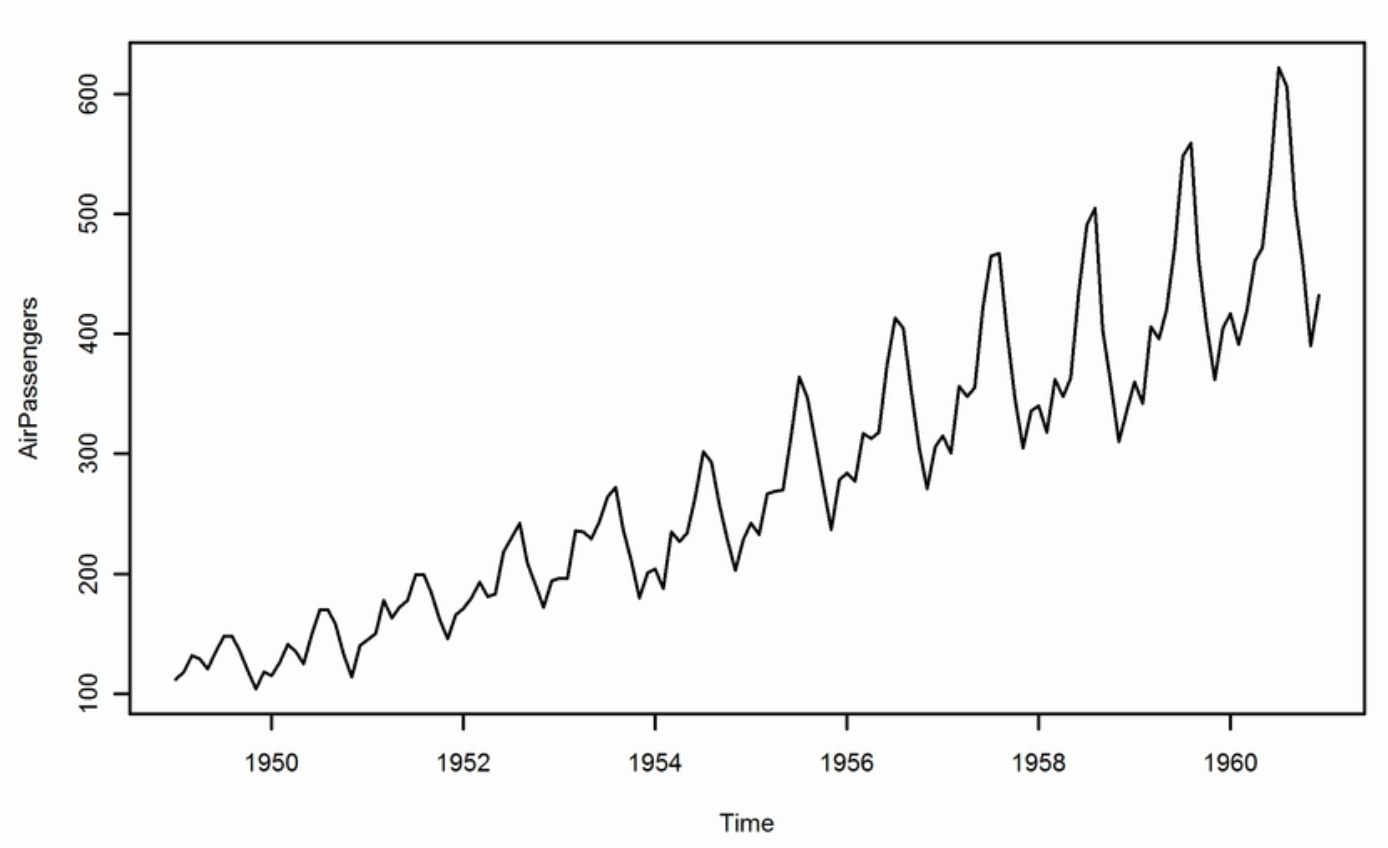  
  
- 계절성: 일정 주기에 따라 반복적으로 나타나는 데이터의 변동 -> 주기적 패턴을 고려한 예측 모델링 가능
- 추세: 시간의 흐름에 따라 나타나는 장기적인 증가/감소 경향 -> 전반적인 방향성 파악
  
3. 자기상관성
- 자기자신끼리 상관관계를 가짐
- 한 시점의 값이 과거의 값과 통계적으로 관련 있는 성질 -> 시간이 지남에 따라 값들 간 일정한 패턴이나 반복 존재
- 관측값은 서로 종속적
- 자기상관성을 파악하면 과거 데이터를 바탕으로 미래 예측 가능
  
> 자기상관성 때문에 회귀분석이 불가능하다!  
  
*Why?*  
  
a. 오차항 독립성 가정 위반 -> 통계 결과 왜곡  
- 회귀분석 기본 가정: 오차들이 서로 독립적이어야 함 -> 이 가정을 위반
  
b. 허위 상관관계 문제  
- 동일한 추세를 가지는 데이터로 상관관계를 돌렸을 때, 둘 사이의 상관관계가 높게 나타날 수 있음 
- 해결 방안: 각 시계열 변수에서 추세를 제거한 후 분석
  
c. 예측의 어려움  
- 잔차가 시간에 따라 패턴 가짐 -> 미래값 예측 왜곡
- 예측 오차가 누적되며 신뢰도 하락
  
d. 모델 복잡성 증가  
- 단순 회귀모형은 적절하지 않음 -> AR, ARIMA 등 시계열 모델로 대체 필요  
  
> 따라서! 시계열 데이터는 AR/MA/ARIMA 같은 시계열 전용 모델을 활용하거나, 사전 처리 후 분석해야 함  
  
  
### 1-3. 시계열 데이터 분석 요인  
  
1. 추세 요인: 데이터 전반에 걸쳐 시간에 따라 지속적으로 증가/감소하는 경향  
  
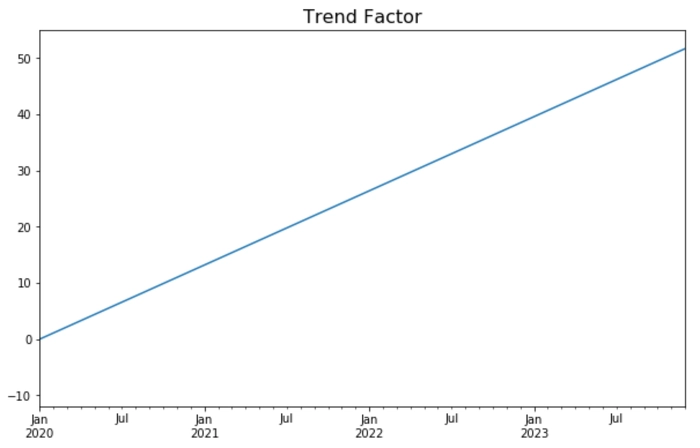  
  
2. 계절 요인: 일정한 주기로 반복되는 패턴  
  
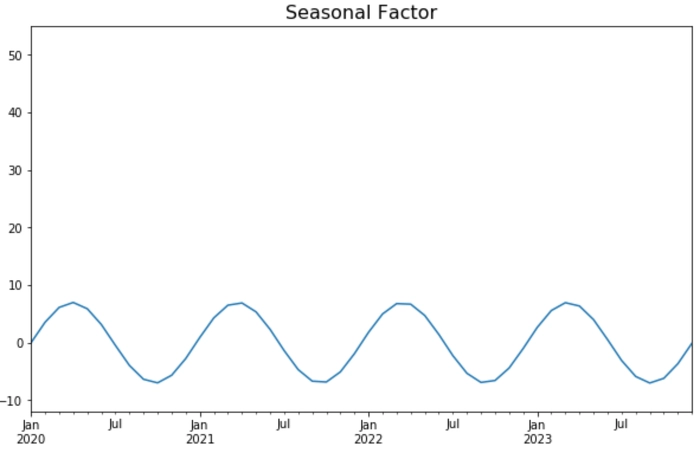  
  
3. 순환 요인: 계절성보다 더 길고 불규칙한 주기로 반복되는 변동  
  
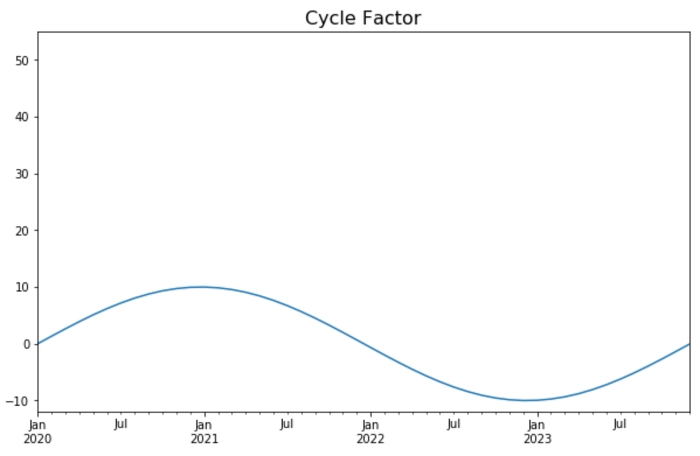  
  
- 고정된 주기로 반복되는 패턴이 있으면 *계절성*, 주기가 불규칙하거나 장기적인 경우 혹은 외부 요인에 의해 발생하는 경우 *순환성*
- 시계열 데이터가 순환 주기보다 짧으면 순환요인 판단 어려움
  
4. 불규칙 요인: 추세, 계절성, 순환서을 모두 제거한 뒤 남은 예측 불가능한 변동  
  
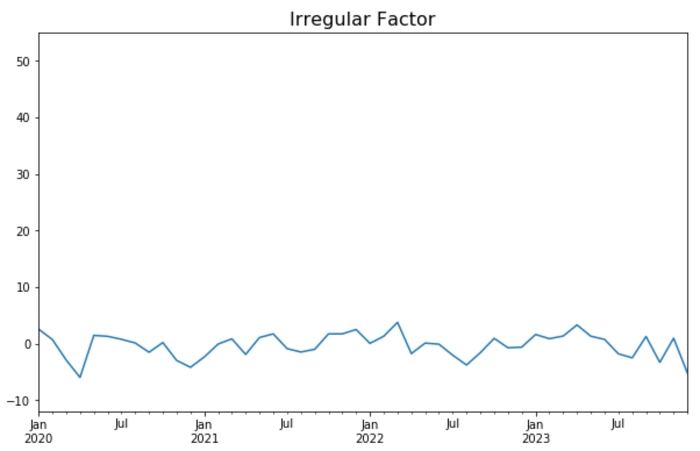  
  
- 노이즈, 우연적 사건, 일시적 변동, 이상치 등 모두 포함  
  

### 1-4. 시계열 분석 work flow  
  
1. 데이터 전처리: 결측치 보간, 이상치 제거, 요소 분해
2. 정상성 판단
3. 모델링 및 예측

## 2. 시계열 데이터 전처리  
  
> 시계열 데이터의 특성이 왜곡되지 않도록, 시계열 특성을 반영한 전처리 필요  
  
[프로세스]  
1. 데이터 확인/시각화
2. 결측치 확인 -> 결측치 처리 (삭제, 단순 대치, 보간, 이동평균 대치 등)
3. 이상치 탐지 -> 이상치 처리 (삭제, 단순 대치, 보간, 이동평균 대치 등)  
4. 평활화 진행 -> 이동평균 이용
5. 요소 분해: 가법 모형, 승법 모형
  
  
### 2-1. 결측치/이상치 탐지 및 처리  
  
1. 시계열 데이터 결측치
- 특정 시점에서 값이 측정되지 않았거나 누락된 상태
- 센서 오류, 수집 누락, 전송 지연 등으로 발생
- 결측치가 존재하면 추세, 계절성이 왜곡되므로 적절한 대치와 보간 필요  
  
**결측치 처리 방법**  
- 삭제: 비어있는 시점의 데이터 제거하는 방식
    - (-) 시간 흐름의 연속성 깨지고 분석 구간 짧아질 수 있음
- 단순 대치: 평균, 중앙값, 최빈값, 0으로 결측치 채움
    - (-) 패턴 왜곡 가능성 큼
- 보간법: 주어진 데이터 포인트 값을 사용하여 두 개 이상의 데이터 포인트 사이에서 누락된 값을 추정 (=사라진 값을 합리적으로 메움)
    - (+) 결측치/이상치 구간이 짧거나 신호의 패턴이 단순할 때 보간 정확도 높음
    - 선형 보간법, 다항식 보간법, 스플라인 보간법, 조각별 상수 보간법
    - 회귀와의 차이: 회귀는 관측 점들의 오차를 가장 적게 만드는 선을 찾음, but 보간법은 관측값을 완전히 신뢰하여 관측값 연결
  

2. 시계열 데이터의 이상치
- 값이 측정되었으나, 측정된 값이 일반적이지 않은 경우
- 측정 오류 혹은 실제로 특이한 이벤트
- 단순히 이상한 값이 아니라 중요한 의미일 수도 있으니 신중히 접근해야 함 -> 신호에 대한 사전 지식 필요
  
**이상치 탐지 방법(전처리)**  
- IQR Rule-based Anomaly Detection  
      
    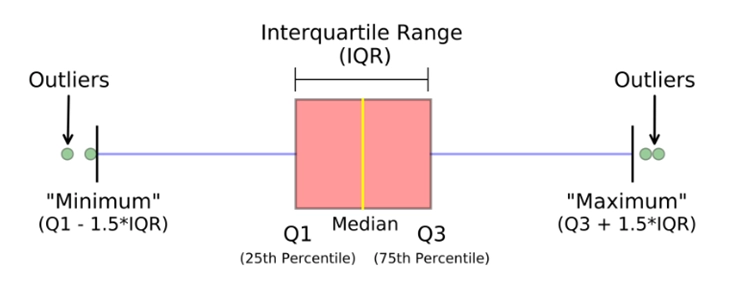  
      
    - 위 조건을 만족하면 이상치로 간주
    - 주기성이 없거나 비교적 안정적인 구간의 값들에서 이상치 탐지할 때 사용
    - 구간별로 나눠서 IQR 계산 시, 추세의 영향 줄일 수 있음
    - (+) 단순하고 해석 명확, 통계 기반이라 빠름
    - (-) 추세나 계절성 강한 시계열에는 부적합, 분포가 비정상적일 경우 오탐률 높음
  
- Z-score: $Z=\frac{(x-\mu)}{\sigma}$
    - 특정 값이 평균으로부터 몇 표준편차 만큼 떨어져 있는지 나타냄
    - Z-score가 특정 임계값을 넘어서면 이상치로 판단 (보통 |Z|>3)
    - 계절성/추세가 약하거나 값의 편동폭 일정한 시계열에서 효과적
    - 구간별로 나눠서 계산 시 추세 영향 줄일 수 있음
    - (+) 계산이 간단하고 빠름, 해석 직관적
    - (-) 정규분포 가정에 민감, 평균과 표준편차가 시간에 따라 변하는 비정상 시계열에서는 안정적 threshold 설정 어려움
  
- STL 분해: $X_t=T_t+S_t+R_t$
    - T: 추세 / S: 계절성 / R: 잔차
    - 잔차가 특정 임계값 초과하면 이상치 탐지
    - 계절성이나 추세 뚜렷한 시계열에 적합
    - 잔차에 대해 z-score, IQR 등 통계적 기준 추가 적용하여 이상 탐지 가능
    - (+) 계절성과 추세를 제거하고 진짜 이상한 값만 잡아냄, 비정상 시계열에도 유연하게 적용 가능
    - (-) 계산 비용 큼(LOESS 회귀 기반), 매우 긴 시계열에는 파라미터 튜닝 필요
        - LOESS 회귀: 전체 데이터에 하나의 직선/곡선을 맞추는 대신 각 지점 주변의 데이터만 이용해 작은 회귀모델 만들고 그 결과를 이어 붙여 부드러운 곡선 맞춤
  
**이상치 탐지 모델**  
- 분류 및 회귀 트리 (CART)  
    - 데이터 분할하여 예측값 산출
    - 예측 오차가 일정 임계값 이상인 지점을 이상치로 간주
    - 회귀트리를 이용할 경우 예측값과 실제값의 차이가 클수록 이상으로 탐지
    - 과거 구간의 값을 입력으로 하여 다음 시점 값 예측하고, 예측값과 실제값 간 예측 오차 기반으로 이상 판단
    - (+) 비선형 관계 잘 포착, 변수간 상호작용이 있는 다변량 시계열에도 적용 가능
    - (-) 노이즈가 많은 데이터에서 과적합 위험, 트리의 깊이에 따라 탐지 민감도 달라짐
  
- 클러스터링
    - 정상 구간 데이터는 특정 클러스터에 잘 모인다는 가정하에, 이상치는 대부분 클러스터 중심에서 멀리 떨어진 outlier cluster나 소수 클러스터로 나타남
    - k-means, DBSCAN, Isolation Forest 등 사용
    - 시계열의 특징을 추출한 후, 각 시점을 벡터로 표현해 클러스터리 수행 (특징 예: 최근 5분 평균, 표준편차, 기울기 등)
    - (+) 데이터의 패턴이 복잡하거나 다변량일 때 유용, 사전 분포 가정 필요 x
    - (-) 하이퍼파라미터에 민감, 시계열의 순서 정보는 직접적으로 반영되지 않음
  
- 오토 인코더
      
    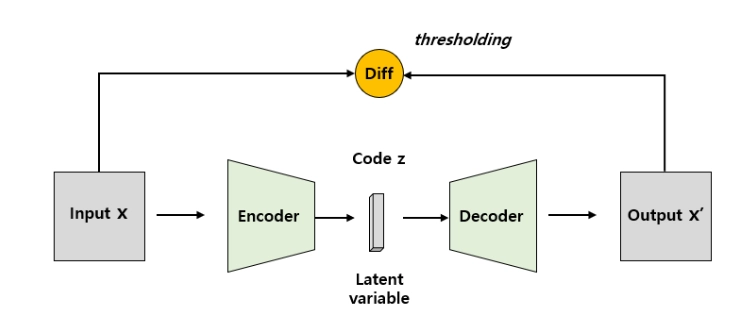  
      
    - 인공신경망 기반 비지도 학습 모델
    - 정상 데이터 특징 학습 -> 학습된 모델에 데이터 입력했을 때 데이터 재구성 -> 재구성한 결과와 학습된 정상 특징과의 차이점을 비교하여 이상 여부 판단
    - 정상 패턴은 잘 복원 되지만, 이상 패턴은 복원오차 커짐
    - 복원 오차가 일정 임계값 이상이면 이상치로 판정
    - LSTM Autoencoder를 사용하면 시계열의 시간적 의존성까지 학습 가능
    - sliding window로 시계열 구간 학습시키고, 테스트 구간의 복원오차로 이상 탐지
    - (+) 복잡한 비선형 패턴 학습 가능, 다변량 시계열 이상 탐지에 특히 강력
    - (-) 학습 데이터 많아야 함, 모델 해석 어렵고 파라미터 튜닝 까다로움 
  
  
**이상치 처리 방법**  
- 이상치를 결측치로 간주 -> 결측치와 같은 방법으로 처리
    - 삭제, 단순 대치, 보간
  

### 2-2. EDA (평활화)  
  
**평활화(smoothing)**: 시계열 데이터에서 노이즈를 줄이고 전체적인 흐름이나 추세를 더 명확히 파악하기 위해 데이터를 부드럽게 만드는 기술  
- 노이즈: 원래 데이터 안에 자연스럽게 섞여 있는 설명 불가능한 랜덤 변동 (오차), 우리가 관측한 데이터에는 신호와 노이즈가 섞여 있음
- 이동평균(MA)
      
    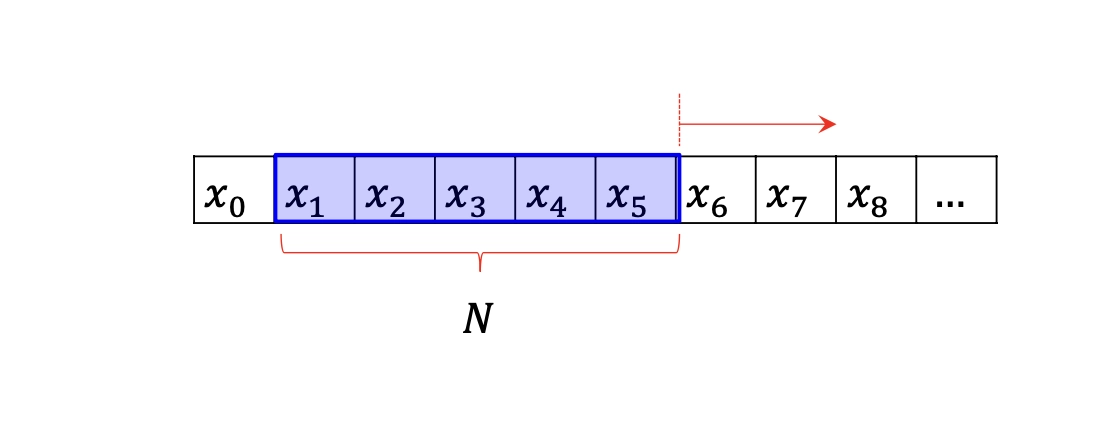  
      
    - N=Moving Window의 길이
    - N이 클수록 긴 기간의 데이터를 평균에 포함 -> 노이즈가 더 많이 제거되어 보다 매끄러운 곡선 생성
    - 사용 목적
        - 노이즈 제거: 일시적인 급등/급락을 평탄화
        - 추세 파악: 상승/하강 흐름을 쉽게 식별
        - 예측의 기초자료: 시계열 예측(ARIMA)의 기반이 되기도 함
    - 유형
        - 단순 이동평균(SMA): 단순히 기간 내 모든 값 평균, 변동 심하지 않고 비교적 안정적인 시계열
        - 가중이동평균(WMA): 최근 값에 더 큰 가중치 부여, 최근 데이터가 더 중요한 상황
        - 지수 이동평균(EMA): 최근 데이터에 지수적으로 더 많은 가중치 부여, 최근 값에 매우 빠르게 반응해야 하는 시계열
  

### 2-3. 요소분해  
  
**요소분해**: 주어진 시계열 데이터를 개별 성분(추세성, 계절성, 순환성, 불규칙성)으로 분해하는 과정  
  
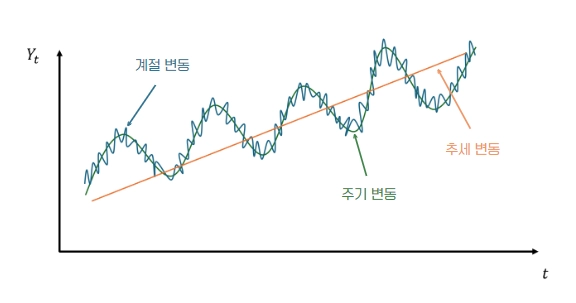  
  
- $Y_t=f(T_t, S_t, C_t, R_t)$
    - T: 추세성분 / S: 계절성분 / C: 순환성분 / R: 불규칙성분
    - 일반적으로 순환성은 장기간에서만 고려되므로 $C_t=0$으로 설정
- 요소분해를 하는 이유
    - 시계열 데이터=추세/계절성/순환성/불규칙성 등 다양한 변동이 결합된 형태
    - 각 요소를 분리하면 각각의 패턴을 명확히 이해 가능
    - 이후 예측, 이상 탐지 등 분석 작업을 정교하게 수행 가능
  

**분해 모형**  
1. 가법모형: $y_t=T_t+S_t+R_t$
- 시계열= 추세+계절성+불규칙성 
- 시계열 관측값은 변동요인들의 가법(+)으로 설명될 수 있다고 가정
- 각 변동 요인들이 독립적으로 더해지며 모든 요소의 영향이 일정
- 시계열 전체에서 계절성의 진폭이 일정할 때 적합
- 추세변동 - 계절변동이 서로 독립적
  
2. 승법모형: $y_t=T_t*S_t*R_t$ -> $\log{(y_t)}=\log{(T_t)}+\log{(S_t)}+\log{(R_t)}$ (로그 변환을 통해 가법 형태로 만들 수 있음)
- 시계열=추세x계절성x불규칙성
- 시계열 관측값은 변동요인들의 승법(*)으로 설명될 수 있다 가정
- 추세가 커질수록 계절성이나 불규칙성의 효과도 비례해서 커짐
- 진폭이 시간에 따라 달라질 때 적합
- 추세변동에 따라 계절변동이 변함
  
  
**분해 방법(구현 알고리즘)**  
1. seasonal_decompose - MA 기반 분해
- 전통적인 시계열 분해 기법
- 이동 평균을 통해 추세를 추출한 뒤 잔여 성분에서 계절성을 분리하는 방식
- 작동 방식
    1. 추세 추출: 중심 이동평균을 적용하여 추세성분 $T_t$ 추정
    2. Detrending: 원 시계열에서 추세를 제거하여 detrended-시계열 생성 ($D_t=Y_t-T_t$)
    3. 계절성 추정: 디트렌드 시계열에서 동일한 계절 인덱스에 해당하는 값들의 평균을 취해 계절 패턴 $S_t$ 도출 -> 이때 연간 평균이 0이 되도록 정규화
    4. 잔차 산출: $R_t=Y_t-T_t-S_t$
  
2. STL-LOESS 기반 분해
- 이동평균 대신 LOESS를 사용
- 추세와 계절성이 시간에 따라 변화하는 경우에도 유연하게 포착 가능, 이상치에 강건한 분해 가능
- 작동 방식: Inner Loop와 Outer Loop의 이중 반복 구조
    - Inner Loop (반복 수렴)
    1. 추세 제거: $Y_t-T_t$
    2. Cycle-subseries 추출 후 각 Subseries에 LOESS 적용
    3. Low-pass filter로 저주파 성분 제거
    4. 계절 성분 $S_t$ 확정
    5. 계절성 제거: $Y_t-S_t$
    6. LOESS로 추세 $T_t$ 갱신
    -> 통상 적으로 2회 반복 수렴
    - Outer Loop: 잔차 크기 기준으로 강건성 가중치 부여해 이상치의 영향력 줄인 후 Inner Loop 재실행
  
**요소분해 정리**  
- 시계열 데이터에 포함된 다양한 변동 요인을 분리해 원본 데이터 명확히 파악
- 복잡한 시계열 그래프를 요소별로 나눠 각 요소를 독립적으로 분석할 수 있음
- 예측 모델링 전에 요소를 분리해두면 각 구성 요소를 개별적으로 모델링하거나 통제할 수도 있어서 정확도 향상 가능 (시계열 예측 모델에 적용)
- 특정 시점에 급격한 변화가 있다면 어느 요소에서 비롯된 것인지 분석할 수 있어 이상 탐지 및 원인 분석 가능

## 3. 정상성 판단  
  
### 3-1. 정상성  
  
> 시간에 상관없이 일정한 성질을 띠고 있다!  
  
**정상성**: 시계열 데이터의 평균, 분산 등 통계적 특성이 시간에 따라 일정한 수준으로 유지되는 것  
- "어제나 오늘이나 데이터의 통계적 특성이 일정"
- 정상 시계열: 정상성을 띠는 시계열 데이터
- 비정상 시계열: 정상성을 띠지 않는 시계열 데이터
- 통계 분석에서 정상성이 중요한 이유
    - 예측 가능: 과거의 패턴과 성질이 미래에도 똑같이 유지될 것이라고 가정할 수 있으므로 통계모델링에 바로 적용하기 좋음
    - 비정상 시계열 데이터는 예측이 어렵기 때문에 수학적인 처리를 거쳐 정상성을 띠도록 변환한 뒤에 분석해야 함
  

### 3-2. 강한 정상성과 약한 정상성  
  
**강한 정상성**: 완벽하지만 비현실적인 기준  
- 시간을 언제로 잡든, 데이터의 확률 분포 자체가 동일한 상태
- 평균, 분산 뿐 아니라 데이터의 왜도, 첨도 등 모든 통계적 특성이 일정
- 현실 데이터는 잡음과 외부 요인 항상 존재하므로 이런 상태는 비현실적
  
**약한 정상성**: 실무에서 쓰는 현실적 기준  
- 평균이 일정: 시간이 지나도 일정한 수준 유지
- 분산이 일정: 데이터의 오르내림 변동 폭이 일정한 수준 유지
- 자기공분산이 시차에만 의존: 데이터 간 관계가 특정 시점이 아니라 시간의 간격에 의해서만 결정
    - 자기공분산: 한 시계열의 다른 시점들 사이의 관계, 양수면 두 시점 과거와 현재가 같은 방향으로 움직이고, 음수면 반대 방향으로 움직임
    - 공분산은 시점이 아닌 시차에 의존!
- 우리에게 필요한 데이터는 약한 정상성 데이터!
  

### 3-3. 정상성 판단  
  
1. 시각적으로 정상성 판단: 정상성을 띄는 시계열 데이터는 그래프로 봤을 때, 일정한 기준선(평균)을 중심으로 일정한 폭으로 진동하는 형태
- 비정상 시계열 특징
    - 추세가 있는 경우: 시간에 따라 데이터 지속적으로 상승하거나 하락
    - 계절성 있는 경우: 1년 등의 특정 주기로 패턴이 반복
- 추세가 뚜렷한 시계열을 정상 시계열로 변환
    - 차분(differencing)한 결과로 해석 가능, 어제 값에서 오늘 값을 뺀 일일변동량으로 계산
  
2. 왜 통계적 검정이 필요할까?
- 그래프만으로는 시각적으로 정상성 여부 판단하기 어려움 -> 이에 따른 수치적인 가설검증 필요 -> 대부분 '단위근'이 있는지를 확인
- 단위근: 과거 충격이 영구적으로 누적되는 특성(대표적인 비정상성의 원인), 시계열이 Random하게 움직이게 만들어 평균으로 회귀하지 않고 분산이 시간에 따라 증가하여 예측이 어려워짐
    - 랜덤워크: 외부 충격으로 인한 변동이 계속 유지되어 한 번 충격을 받으면 원상태로 돌아가지 못하는 현상 (ex. 주가)
  
  
**단위근 검정 방법**: ADF, KPSS  
  
1. ADF(Augmented Dickey-Fuller) 검정
  
> 이 시계열이 비정상이 아님을 증명  
  
- 단위근의 존재 여부를 검정하여 시계열의 정상성 판단
- 귀무가설: 단위근이 존재한다 (=비정상 시계열)
- 대립가설: 단위근이 존재하지 않는다 (=정상 시계열)
- 시계열이 과거 값에 얼마나 의존하는지 측정 -> 과거 값의 영향이 시간이 지남에 따라 점점 사라지면 정상 시계열, 누적되어 사라지지 않으면 단위근이 존재하는 비정상 시계열  
  
2. KPSS(Kwiatkowski-Phillips-Schmidt-Shin) 검정
  
> 이 시계열이 정상임을 반증  
  
- ADF의 검정력이 낮은 한계를 보완하기 위해 함께 사용
- 귀무가설: 단위근이 존재하지 않는다 (=정상 시계열)
- 대립가설: 단위근이 존재한다 (=비정상 시계열)
- 시계열이 일정한 평균 수준을 유지하는지 측정 -> 평균이 시간에 따라 흔들리지 않으면 정상, 평균 자체가 계속 변하고 있으면 비정상
  
*ADF와 KPSS를 같이 돌리고 둘의 결과 조합에 따라 다음 액션 수행*  
- ADF 정상, KPSS 정상: 정상 시계열 -> 그대로 모델링
- ADF 비정상, KPSS 비정상: 단위근 존재(확률적 추세) -> 차분 적용
- ADF 비정상, KPSS 정상: 확정적 추세 의심 -> 추세 제거 or 추세항 모델링
  
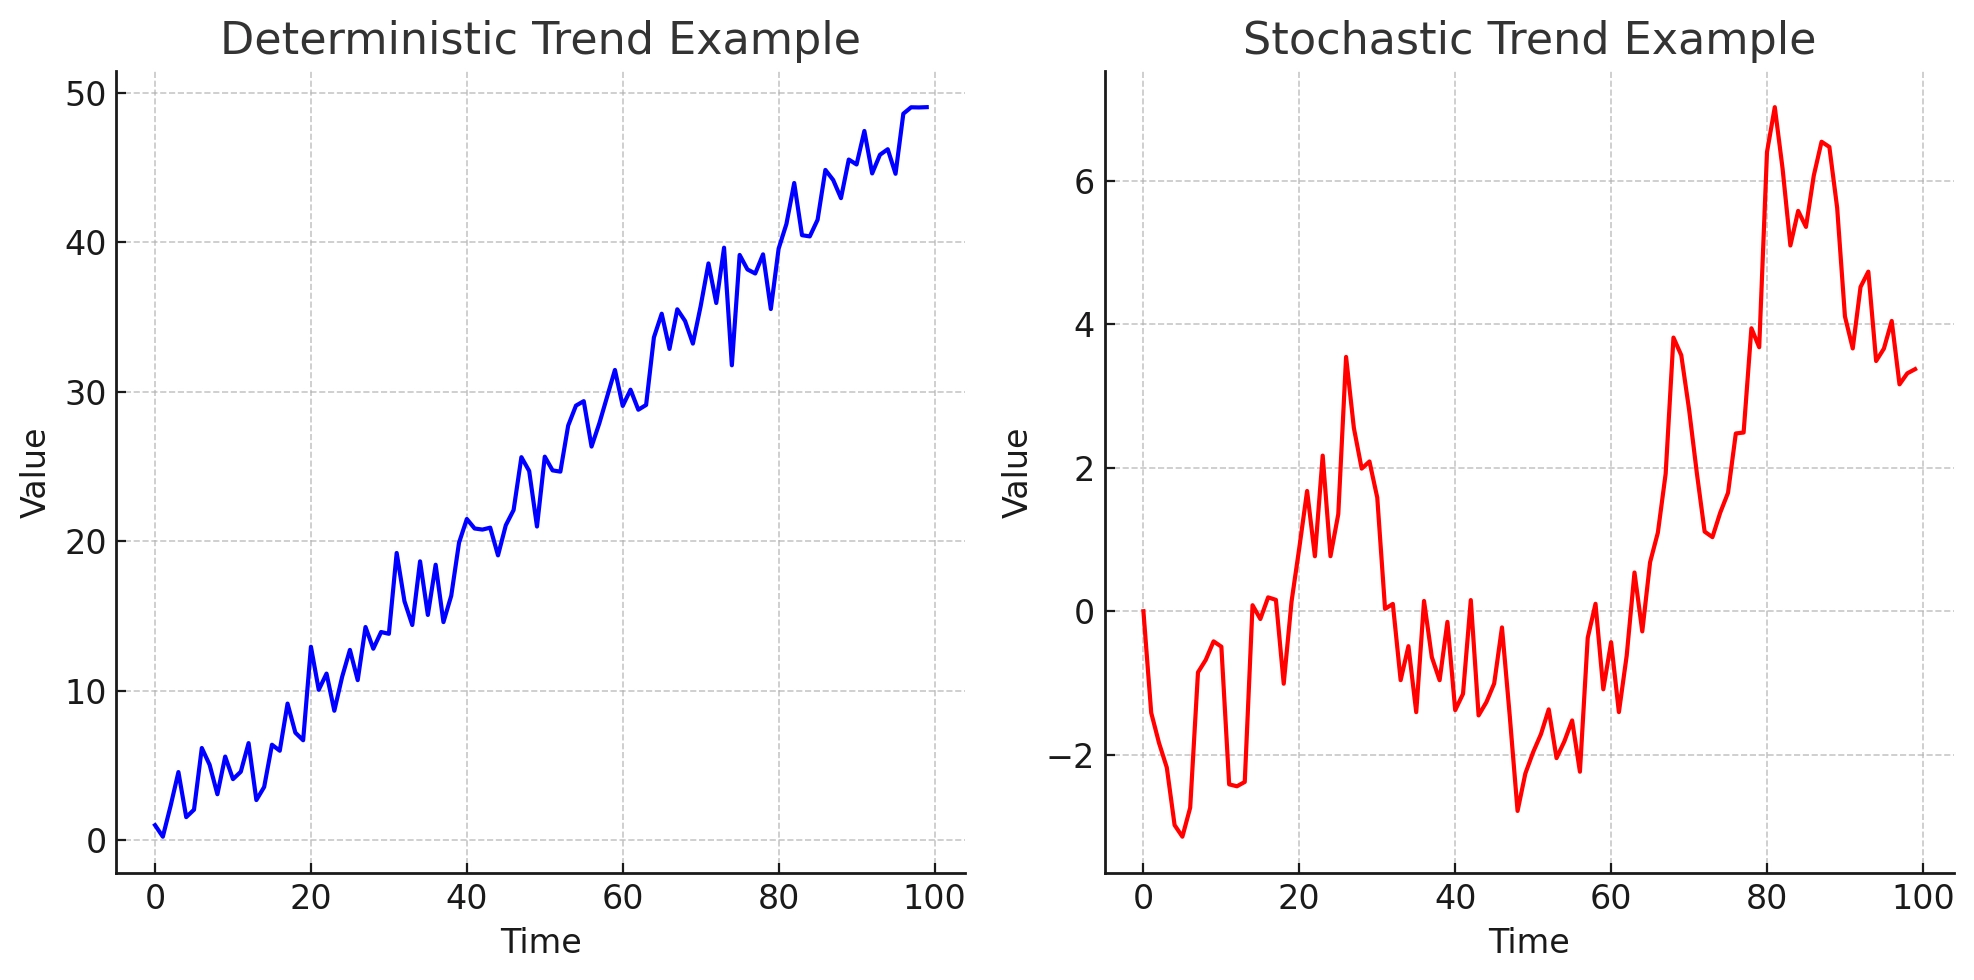  
  
- 좌: 확정적 추세 / 우: 확률적 추세
    - 확정적 추세: 추세가 완벽하게 예측 가능하고 일정하게 존재
    - 확률적 추세: 추세선 자체가 시간에 따라 이동 (랜덤워크)
  

### 3-4. 정상성 확보를 위한 방법들  
  
**비정상 시계열**: 대부분 추세가 있거나, 계절성이 있거나, 분산에 변동 존재
- 추세를 제거하거나(디트렌딩), 계절성을 제거하거나(디시즈닝), 분산을 일정하게 만들자
- 미리 EDA를 찍어보고 추세 띄는지 계절성 띄는지 파악 -> 제거
- 최종적으로 시계열은 정상성을 띠게 됨
  
1. 추시 제거: 시계열이 지속적으로 증가하거나 감소할 때 적용
- 차분: 연이은 관측값들의 차이를 계산하는 것 (=평균의 정상성을 확보하기 위한 방법)
    - 1차 차분, 2차 차분, 역차분(차분했던 걸 복원)
- 시계열 데이터에서 한 시점의 값과 그 이전 시점의 값을 차분하여 변화량을 계산 -> 시계열 데이터의 정상성을 확보하거나 비정상적인 변동을 제거할 수 있음
  
2. 계절성 제거: 시계열이 주기적 패턴을 가질 때 적용
- 계절 차분: $y_t^*=y_t-y_{t-m}$, t시점의 y값에서 t-m 시점의 y값을 빼는 것 (m: 주기의 길이)
- 차분을 통해 완전히 random한 데이터를 뽑아낼 수 있음! (이전의 데이터와 상관성이 없는 데이터라 가정하고 분석할 수 있게 됨)
- but, 데이터에서 계절성 패턴이 강하게 나타나면 계절성 차분을 먼저 진행하는 것이 좋음 -> 계절성 차분을 한 이후에 시계열에서 정상성이 나타나기도 하기 때문에 1차 차분을 구할 필요가 없게 되기 때문
- if 1차 차분을 먼저 계산 -> 여전히 남아있는 계절성 나타날 것
  
3. 분산 안정화: 시계열의 변동 폭이 점점 커지거나 작아질 때 적용
- 로그 변환: 분산의 정상성 확보하기 위한 방법
    - 로그의 밑을 10으로 사용하면 로그 눈금에서 1만큼 증가하는 것이 원래 눈금에서 10배 증가한 것과 대응(=로그를 취하면 변화폭 줄어듦)
      
    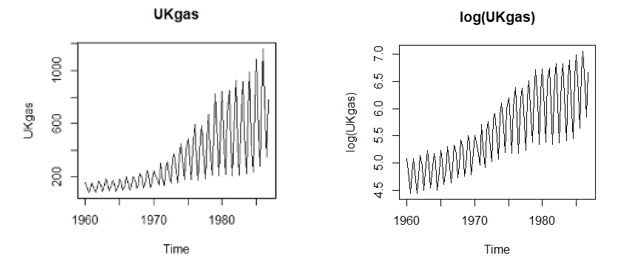  
      
    - (-) 음수나 0처리 불가, 분산 변화가 비선형적이거나 복잡한 패턴을 가질 경우 충분치 않음
  
> 시계열 분석은 결국 '정상성 확보 -> 패턴 파악 -> 적절한 모델링의 순환적 과정  
  
- 정상/비정상 여부 판단
    - 단위근 검정 사용 (ADF, KPSS)
    - 비정상이면 -> 다음 단계로 이동
- 정상성 확보
    - 추세: 차분, 추세 제거
    - 계절성: 계절 차분, Deseasoning
    - 분산 변화: 로그변환, Box-Cox 변환
- 정상성 확보 후 어떤 프로세스를 따르는지에 따라 모델링
    - AR, MA, ARMA, SARIMA 등

## 4. 단변량 시계열 분석  
  
### 4-1. 안정적 시계열 분석  
  
1. 자기 회귀 모델(AR, Autoregressive Model)  
  
**자기 회귀**: 과거의 자기 자신 데이터가 미래 값을 설명해줄 것이라고 가정하는 것  
- 과거 자신의 값을 독립변수로 삼아 현재 값을 예측하는 회귀
- 시계열 데이터의 자기상관성을 활용
    - 자기상관성: 이전 시점의 값이 이후 시점에 영향을 미침
- $AR(p): y_{t}=c +\phi _1y_{t-1}+\phi_2y_{t-2}+...+\phi _py_{t-p}+\varepsilon _t$ -> p차 자기 회귀 모형
    - 과거 p개 시점의 데이터의 선형 조합을 이용해 예측하는 모델
- MLE(최대우도추정) 기반으로 파라미터 $\phi$를 추정
  
2. 이동 평균 모델(MA, Moving Average)
  
**이동 평균**: 어제의 충격이 오늘의 결과에 영향을 준다고 가정  
- 과거 시점의 잔차를 독립변수로 삼에 현재 값을 예측하는 모델
- 잔차들은 모두 백색잡음&서로 독립적
    - 백색잡음: 평균0, 분산 일정, 과거 값 영향 받지 않고, 오로지 외부 충격(오차항)에 의해서만 결정
- $MA(q): y_t = \mu +\varepsilon _t+ \theta _1\varepsilon_{t-1}+\theta_2\varepsilon_{t-2}+...+\theta_q\varepsilon_{t-q}$ -> q차 이동 평균 모형
    - 과거 q개의 예측 오차의 선형 결합으로 예측하는 모델
  
3. AR, MA 모델의 전제 조건: 데이터의 특성+모델 구조의 안정성을 고려해야 함
  
**정상성**: AR과 MA 모형은 안정적 시계열 분석으로 확률적 안정성을 전제로 추정 -> 모델 구조도 정상성을 만족해야 함  
- AR 모형의 정상성 조건: 특성 방정식의 모든 해(z)의 절댓값>1 => AR 정상성 확보
    - 특성방정식: 시차를 k만큼 뒤로 가게 해주는 연산자인 Lag-operator를 활용해 AR(p) 모형을 변환한 것
- MR 모형의 정상성 조건: 잔차들은 정상성을 이미 만족하므로, 잔차들의 조합으로 이뤄진 MA 모형도 항상 정상성 만족!
  
**가역성**: MA 모형을 AR(∞) 형태로 재표현할 수 있는지 여부
- 오차항 $\varepsilon _t$을 $y_t, y_{t-1},...$로 다시 표현할 수 있는가
- MA 모형에서는 현재 시점의 값을 과거 시점의 오차항으로 예측 -> but 오차항은 직접 관찰 불가 -> 따라서 오차항도 관측 가능한 과거값($y_{t-n}$)으로 표현할 수 있어야 안정적
- AR 모형의 가역성 만족 조건: AR 모형은 처음부터 AR 형태라 가역성 체크 안해도 됨
- MA 모형의 가역성 만족 조건: 특성방정식 모든 해(z)의 절댓값>1
  
  
4. ARMA(Autoregressive Moving Average) 모형
  
$$ AR(p)+MA(q) \rightarrow ARMA(p,q)$$
  
- AR 모형과 MA 모형을 결합
    - 과거 p개의 관측값+과거 q개의 오차를 활용해서 예측하는 방법
    - 조건: AR(p) 모형의 정상성+MA(q) 모형의 가역성 -> 이 둘의 조건 모두 만족해야 함
- ARMA 모형의 특수한 경우
    - ARMA(p,0): AR(p)와 동일!
    - ARMA(0,q): MA(q)와 동일!
    - ARMA(0,0): 백색 잡음 모델($y_t=\varepsilon _t$)과 동일!
        - 백색 잡음 모델: 아무런 패턴이 없는 무작위한 변화
  
  
5. 차수 결정 방법: 자기 상관 함수
- 두 그래프를 통해 현재 값이 과거 값과 어떤 관계가 있는지 파악하고 이를 통해 AR, MA, ARMA의 적절한 차수(p,q)를 결정
- 자기 상관 계수(Auto Correlation Function, ACF)
    - ARMA(p,q) 모형에서 사용할 q개의 오차 결정 방법
    - 두 시점 사이의 상관 관계 파악(간접 영향까지 모두 파악)
    - 시차(lag) k에 대해서, 두 관측치 간 상관 관계를 나타냄
- 부분 자기 상관 계수(Partial Autocorrelation Function, PACF)
    - ARMA(p,q) 모형에서 사용할 p개의 시점 결정 방법
    - 두 시점 사이의 직접적인 영향만 파악
    - 시차(lag) k에 대해서 두 시점 사이의 순수한 상관 관계를 나타내는 함수
        - 순수한 상관 관계? -> 두 시점 사이의 다른 시점들과의 상호 의존성은 모두 제거 (=두 시점이 직접 미치는 영향만 분석)
- ACF와 PACF로 차수 및 모형 결정하기
    - ACF 천천히 감소, PCAF p+1 시점부터 0에 근접 -> AR(p), p=절단 시점
        - 과거 p개의 데이터의 선형 결합으로 예측
        - ACF: 천천히 감소 = AR 모델은 과거 값이 계속 영향, 현재의 값이 여러 시차의 과거 값과 약하게 연결
        - PCAF: p+1 시점으로부터 0으로 절단 = 시점 p까지만의 과거만이 현재에 영향, 그 이후는 더 이상 직접적 영향 x
    - ACF q+1 시점부터 0에 근접, PCAF 천천히 감소 -> MA(q), q= 절단 시점
        - 과거 q개의 예측오차의 선형 결합으로만 예측
        - ACF: q+1 시점부터 0으로 절단 = MA 모델은 q시점까지만 과거 오차항의 영향, 그 이후는 더 이상 오차 영향 x
        - PCAF: 천천히 감소 = 현재값은 과거 오차항의 조합이므로 오차항이 만들어내는 간접 상관이 존재, 멀리 떨어진 시점 간에도 상관성 존재
    - ACF q+1 시점부터 0에 근접, PCAF p+1 시점부터 0에 근접 -> ARMA(p,q)
  

### 4-2. 불안정 시계열 분석  
  
[프로세스]  
a. 비정상 시계열 데이터 (추세 or 계절성 존재)  
b. 정상성 확보 (차분 or 계절성 차분)  
c. 정상 시계열  
d. ARMA를 사용해 안정적 시계열 분석  
(불안정 시계열 모델은 안정적 시계열 모델에 정상성 확보 과정이 추가된 형태)  
  
1. ARIMA(Autoregressive Integrated Moving Average)
  
$$ ARMA(p,q)+차분 \rightarrow ARIMA(p,d,q)$$
  
- ARIMA 모형의 특수한 경우
    - 백색잡음: ARIMA(0,0,0)
    - 자기회귀: ARIMA(p,0,0) <-> AR(p)
    - 이동평균: ARIMA(0,0,q) <-> MA(q)
    - 랜덤워크: 상수가 없는 ARIMA(0,1,0)
        - 방향성이 존재하지 않음
    - 표류를 포함하는 랜덤워크: 상수가 있는 ARIMA(0,1,0)
        - 방향성이 존재함
  

2. SARIMA(Seasonal ARIMA)
  
$$ARIMA(p,d,q)+계절성(Seasonal)차분 \rightarrow SARIMA(p,d,q)(P,D,Q)_{m}$$
  
- 시계열 데이터의 계절성을 처리할 수 있는 모델
- ARIMA 모델에 계절성 변동을 반영한 모델
- 하이퍼파라미터
    - $(p,d,q)$: 비계절 ARIMA 파라미터
        - p: AR의 차수 / d: 차분의 정도 / q: MA의 차수
    - $(P,D,Q)$: 계절 ARIMA 파라미터
        - P: 계절성 AR의 차수 / D: 계절성 차분의 정도 / Q: 계절성 MA의 차수
    - $m$: 계절성 주기의 길이
  
  
**계절성 데이터에서의 ACF와 PCAF**  
- 계절 주기 m(ex.m=12)에서는, ACF에서 m의 배수 lag(ex. 12, 24,...)에서 급등하는 모습  
  
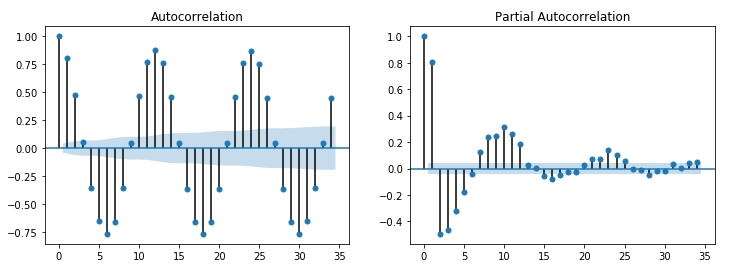  
  
- 위 그래프를 살펴보면, 대략 12 시점을 기준으로 ACF(k)의 값이 급등하는 모습 발견 가능
- 이러한 계절성 추세 때문에 비계절성 추세 파악 어려움
    - 계절성 차분을 먼저 수행하고, 비계절성 차분을 수행해줘야 함
  
  
**불안정 시계열에서의 하이퍼파라미터 결정 방법**  
  
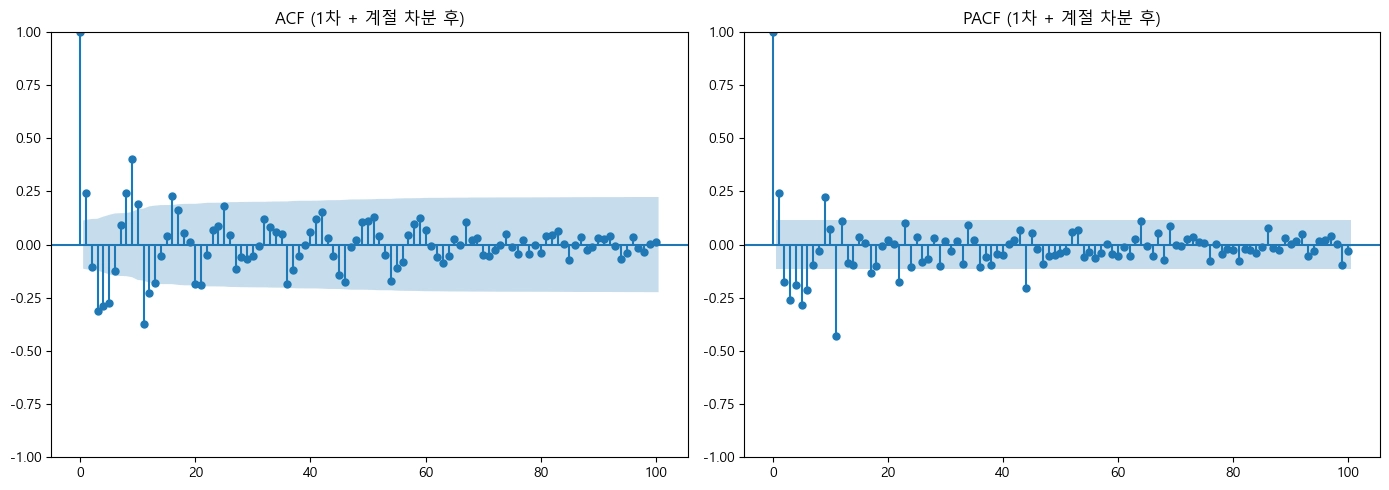  
  
1. d, D(차분, 계절차분) 결정
    - ADF(단위근 검정)으로 정상성 확보 여부 판단 후 결정
        - 데이터가 정상성 갖출 때 -> d, D 결정
        - 차분 정도는 대부분 0 or 1에서 결정됨
  
2. p,q(AR, MA 차수) 결정
    - 먼저 ACF, PCAF로 범위 추정
    - AIC, BIC 같은 정보 기준으로 그리드 서치 후 최종 선택
        - 보통 p,q를 0~3 범위 내에서 그리드 서치 진행


## 5. 다변량 시계열 분석  
  
**VAR(Vector Autoregression)**  
  
> 자신의 과거 값과 다른 변수들의 과거 값을 함께 사용하여 미래를 예측하는 모델  
  
- 단변량 AR: X는 자기 자신의 과거만 사용
- 다변량 VAR: X와 Y가 서로의 과거를 함께 사용
    - VAR에 사용할 변수는 Granger Causality Test를 통해 고름
  
- 적합한 경우
    - 변수들이 서로 영향을 주고 받는 경우
    - 경제, 금융 지표처럼 상호 의존성이 중요한 경우
- 부적합한 경우
    - 변수가 너무 많은 경우(파라미터 폭발)
    - 변수 간 관계가 명확하지 않은 경우
    - 장기 예측이 필요한 경우
  
  
**VAR 모델을 활용한 분석 방법**  
  
1. 충격 반응 함수(IRF, impulse-Response Function)
- 한 변수의 충격이 다른 변수에 미치는 영향을 시간 흐름에 따라 분석
  
2. 예측오차 분산 분해(Variance Decomposition)
- 예측 오차에 각 변수가 얼마나 기여하는지 분석

## 6. 딥러닝을 활용한 시계열 분석  
  
**전통 통계 모델 한계**  
- 데이터 많으면 처리 속도 느려짐
- 크기가 고정된 데이터만 가능
- 비선형 패턴 포착 어려움  
=> 딥러닝을 통해 해결해보자!  

1. 순환 신경망 (RNN/LSTM/GRU)
- 적합한 경우: 주가, 센서, 재무, 사용자 행동 로그
    - 순차적 패턴이 중요한 시계열 데이터
    - 과거 정보가 미래 예측에 영향을 주는 문제
    - 시계열 길이와 목적에 따라 모델 선택 가능
- 부적합한 경우
    - 매우 긴 시계열 (학습 어려움)
    - 병렬 처리 효율 낮음
    - Transformer 계열 대비 학습 속도 느린 편
  

2. Transformer 계열
- Informer: 장기 예측 특화
    - 불필요한 연산을 줄여 계싼 복잡도를 대폭 낮춤
    - 매우 긴 시계열 데이터 처리에 강력
- Autoformer: 주기성 포착 특화
    - 시계열의 전통적 기법인 요소 분해(추세/계절성) 개념을 딥러닝 구조에 직접 결합한 모델
    - 연간 계절성 등 주기 패턴이 뚜렷하게 나타나는 판매량 예측에 압도적인 성능
- TFT(Temporal Fusion Transformer): 실무 활용도 1위
    - 과거 데이터뿐만 아니라 다양한 외부 변수를 섞어서 예측할 수 있는 다목적 아키텍처
    - 어떤 변수가 예측에 가장 중요했는지 어텐션 스코어를 통한 해석이 가능해, 설명력이 중요한 유통/비즈니스 수요 예측에 많이 쓰임
  

3. Foundation 모델: 거대한 데이터로 사전 학습하여 다양한 문제를 해결할 수 있는 범용 모델
- 특징: 특정 문제 전용 X (=범용적), 사전 학습 후 Fine-tuning으로 특화
- LLM 기반 모델: LLM을 시계열 분석에 활용 (ex. prompting, fine-tuning)
- 시계열 전용 Foundation Model: 시계열 데이터로 사전 학습된 범용 모델 (ex. TimeGPT, TimesFM, Moirai, Chronos)
- LLM 기반 모델 활용 방식
    - without adaptation: LLM이 이미 시계열 지식 가지고 있다고 가정 -> 프롬프트 엔지니어링에 집중
    - adapt LLM: LLM을 시계열 데이터로 fine-tuning
    - adapt to LLM: 시계열을 텍스트로 변환 후 LLM 활용 (ex. 숫자 시계열 -> "값이 증가 추세", "주기성 있음")
  
  
4. 딥러닝 모델 선택 가이드
- 핵심 트레이드오프
    - 단순함 vs 성능: RRN < LSTM/GRU < Transformer
    - 해석 가능 vs 정확도: 통계 모델 < 딥러닝
    - 학습 시간 vs 예측 성능: 간단한 모델은 빠르고, 복잡한 모델은 정확함
    - 데이터 크기: 적으면 통계모델/RNN, 많으면 Transformer 적합
- 상황별 추천 모델
    - 짧은 시계열: 통계모델, RNN
    - 중간 길이: LSTM, GRU
    - 매우 긴 시계열: Informer, Autoformer
    - 장기 의존성 중요: LSTM, Transformer
    - 주기 패턴 뚜렷: Autoformer
    - 외생 변수 많음: TFT
    - 대규모 데이터: Transformer 계열
    - 범용 예측 필요: Foundation Model 
